# Data Preprocessing and Feature Engineering

This notebook merges drug response with gene expression data, selects top variable genes, and creates train/test splits.

**Output:** Processed data saved to `data/processed/`

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os

pd.set_option('display.max_columns', 50)

In [3]:

drug_response = pd.read_excel('../data/raw/GDSC2_fitted_dose_response_27Oct23.xlsx')
expression_raw = pd.read_csv('../data/raw/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv')
model_info = pd.read_csv('../data/raw/Model.csv')

print("Data loaded successfully")
print(f"Drug response: {drug_response.shape}")
print(f"Expression: {expression_raw.shape}")
print(f"Model info: {model_info.shape}")

Data loaded successfully
Drug response: (242036, 19)
Expression: (1754, 19221)
Model info: (2132, 49)


In [4]:
expression_default = expression_raw[expression_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
expression_default = expression_default.set_index('ModelID')
metadata_cols = ['SequencingID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC', 'Unnamed: 0']
gene_cols = [col for col in expression_default.columns if col not in metadata_cols]
expression_clean = expression_default[gene_cols]

if 'Unnamed: 0' in expression_clean.columns:
    expression_clean = expression_clean.drop(columns=['Unnamed: 0'])

print(f"Clean expression: {expression_clean.shape}")

Clean expression: (1699, 19215)


In [5]:
sanger_to_model = model_info[['SangerModelID', 'ModelID']].dropna()
sanger_to_model = sanger_to_model.set_index('SangerModelID')['ModelID'].to_dict()
print(f"ID mapping created: {len(sanger_to_model)} entries")

ID mapping created: 1217 entries


In [6]:
drug_counts = drug_response.groupby('DRUG_NAME').size().sort_values(ascending=False)
print("Top 10 drugs by number of cell lines tested:")
print(drug_counts.head(10))

# Select top 3 drugs
selected_drugs = drug_counts.head(3).index.tolist()
print(f"\nSelected drugs: {selected_drugs}")

Top 10 drugs by number of cell lines tested:
DRUG_NAME
Ulixertinib     1698
Oxaliplatin     1684
Fulvestrant     1680
Selumetinib     1666
Dactinomycin    1659
Docetaxel       1637
Uprosertib      1634
GSK343          1634
Acetalax        1434
MG-132           969
dtype: int64

Selected drugs: ['Ulixertinib', 'Oxaliplatin', 'Fulvestrant']


In [7]:
drug_filtered = drug_response[drug_response['DRUG_NAME'].isin(selected_drugs)].copy()
print(f"Filtered drug response: {drug_filtered.shape}")
print(f"\nRecords per drug:")
print(drug_filtered['DRUG_NAME'].value_counts())

Filtered drug response: (5062, 19)

Records per drug:
DRUG_NAME
Ulixertinib    1698
Oxaliplatin    1684
Fulvestrant    1680
Name: count, dtype: int64


In [8]:
drug_filtered['ModelID'] = drug_filtered['SANGER_MODEL_ID'].map(sanger_to_model)
drug_filtered = drug_filtered.dropna(subset=['ModelID'])
print(f"After adding ModelID: {drug_filtered.shape}")

After adding ModelID: (5053, 20)


In [9]:
valid_model_ids = set(expression_clean.index)
drug_filtered = drug_filtered[drug_filtered['ModelID'].isin(valid_model_ids)]
print(f"After filtering for expression data: {drug_filtered.shape}")
print(f"Unique cell lines: {drug_filtered['ModelID'].nunique()}")

After filtering for expression data: (3809, 20)
Unique cell lines: 712


In [10]:
datasets = {}

for drug in selected_drugs:
    # Get drug response for this drug
    drug_data = drug_filtered[drug_filtered['DRUG_NAME'] == drug][['ModelID', 'LN_IC50']].copy()
    drug_data = drug_data.drop_duplicates(subset=['ModelID'])
    drug_data = drug_data.set_index('ModelID')
    
    # Merge with expression
    merged = expression_clean.loc[expression_clean.index.isin(drug_data.index)].copy()
    merged['LN_IC50'] = drug_data.loc[merged.index, 'LN_IC50']
    
    datasets[drug] = merged
    print(f"{drug}: {merged.shape[0]} samples, {merged.shape[1]-1} genes")


Ulixertinib: 709 samples, 19215 genes
Oxaliplatin: 712 samples, 19215 genes
Fulvestrant: 711 samples, 19215 genes


In [11]:
main_drug = selected_drugs[0]
data = datasets[main_drug].copy()
print(f"Using {main_drug} as main drug")
print(f"Dataset shape: {data.shape}")

Using Ulixertinib as main drug
Dataset shape: (709, 19216)


In [12]:
X = data.drop(columns=['LN_IC50'])
y = data['LN_IC50']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe())


Features shape: (709, 19215)
Target shape: (709,)

Target statistics:
count    709.000000
mean       2.764553
std        1.407169
min       -2.503838
25%        1.938525
50%        2.808662
75%        3.647836
max        7.283865
Name: LN_IC50, dtype: float64


Gene variance range: 0.0000 to 16.3688


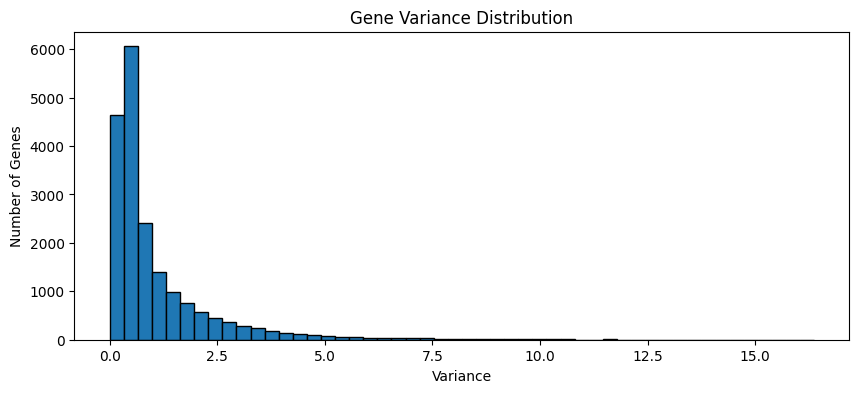

In [13]:
gene_variance = X.var().sort_values(ascending=False)
print(f"Gene variance range: {gene_variance.min():.4f} to {gene_variance.max():.4f}")

# Plot variance distribution
plt.figure(figsize=(10, 4))
plt.hist(gene_variance.values, bins=50, edgecolor='black')
plt.xlabel('Variance')
plt.ylabel('Number of Genes')
plt.title('Gene Variance Distribution')
plt.savefig('../reports/figures/gene_variance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
top_genes = gene_variance.head(1000).index.tolist()
X_selected = X[top_genes]

print(f"Selected {len(top_genes)} genes")
print(f"New features shape: {X_selected.shape}")


Selected 1000 genes
New features shape: (709, 1000)


In [15]:
print(f"Missing values in features: {X_selected.isna().sum().sum()}")
print(f"Missing values in target: {y.isna().sum()}")
X_selected = X_selected.fillna(X_selected.mean())

Missing values in features: 0
Missing values in target: 0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 567 samples
Test set: 142 samples


In [17]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("Features normalized")
print(f"Train mean: {X_train_scaled.mean().mean():.6f}")
print(f"Train std: {X_train_scaled.std().mean():.6f}")

Features normalized
Train mean: 0.000000
Train std: 1.000883


In [18]:
os.makedirs('../data/processed', exist_ok=True)

X_train_scaled.to_csv('../data/processed/X_train.csv')
X_test_scaled.to_csv('../data/processed/X_test.csv')
y_train.to_csv('../data/processed/y_train.csv')
y_test.to_csv('../data/processed/y_test.csv')

with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../data/processed/selected_genes.pkl', 'wb') as f:
    pickle.dump(top_genes, f)

print("Saved to data/processed/")

Saved to data/processed/


In [19]:
print("="*50)
print("PREPROCESSING COMPLETE")
print("="*50)
print(f"Drug: {main_drug}")
print(f"Total samples: {len(y)}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Features: {X_train_scaled.shape[1]} genes")
print("="*50)

PREPROCESSING COMPLETE
Drug: Ulixertinib
Total samples: 709
Training samples: 567
Test samples: 142
Features: 1000 genes
